In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
from scipy import linalg
import torch
from sklearn.manifold import TSNE
import umap.plot
from sklearn.preprocessing  import MinMaxScaler
from Bio import SeqIO

/doctorai/marinafr/progs/miniconda3/envs/airr_atlas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Numpy implementation of the Frechet Distance.
    The Frechet distance between two multivariate Gaussians X_1 ~ N(mu_1, C_1)
    and X_2 ~ N(mu_2, C_2) is
            d^2 = ||mu_1 - mu_2||^2 + Tr(C_1 + C_2 - 2*sqrt(C_1*C_2)).

    Stable version by Dougal J. Sutherland.
    Params:
    -- mu1:    The mean of the activations of preultimate layer of the
               CHEMNET (like returned by the function 'get_predictions')
               for generated samples.
    -- mu2:    The mean of the activations of preultimate layer of the
               CHEMNET (like returned by the function 'get_predictions')
               for real samples.
    -- sigma1: The covariance matrix of the activations of preultimate layer
               of the CHEMNET (like returned by the function 'get_predictions')
               for generated samples.
    -- sigma2: The covariance matrix of the activations of preultimate layer
               of the CHEMNET (like returned by the function 'get_predictions')
               for real samples.
    Returns:
    --   : The Frechet Distance.
    """

    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    assert (
        mu1.shape == mu2.shape
    ), "Training and test mean vectors have different lengths"
    assert (
        sigma1.shape == sigma2.shape
    ), "Training and test covariances have different dimensions"

    diff = mu1 - mu2

    # product might be almost singular
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # numerical error might give slight imaginary component
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            #raise ValueError("Imaginary component {}".format(m))
            print("Imaginary component {}".format(m))
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean

In [3]:
def get_w2(act1, act2):

    """Calculate w2 between two sets

    Args:
        act1: First set
        act2: Second set

    Returns:
        float: The FCD score
    """

    mu1 = np.mean(act1, axis=0)
    sigma1 = np.cov(act1.T)

    mu2 = np.mean(act2, axis=0)
    sigma2 = np.cov(act2.T)

    fcd_score = calculate_frechet_distance(
        mu1=mu1, mu2=mu2, sigma1=sigma1, sigma2=sigma2
    )

    return fcd_score

In [ ]:
model_name = 'antiberta2'

if model_name == 'antiberta2':
    short_model_name = 'ab2'
else: 
    short_model_name = model_name

data = torch.load(f'<UPDATE_PATH>') # TODO: update path to your data).numpy()

len(data)

800000

In [7]:
# Split the data into two halves
data1 = data[:len(data) // 2]
data2 = data[len(data) // 2 + 1:]

splits = [int(x) for x in [10**4, 3*10**4, 5*10**4, 10**5, 1.5*10**5, 2*10**5, 3*10**5, 4*10**5-100]]
w2_data = []

num_repetitions = 10

for repetition in range(num_repetitions):
    print(repetition+1)
    w2_repetition = []

    # Shuffle data2 to ensure randomization
    np.random.shuffle(data2)

    for batch_size in splits:
        print(batch_size)
        max_start = len(data2) - batch_size
        if max_start <= 0:
            print('break')
            break
        start = np.random.randint(0, max_start)
        batch = data2[start:start + batch_size]
        w2_repetition.append(get_w2(batch, data1))
        print(get_w2(batch, data1))

    w2_data.append(w2_repetition)

# Create a DataFrame for boxplot
df = pd.DataFrame(w2_data, columns=splits)

df.to_csv(f"completeness_ots_{short_model_name}.csv", index=False)

df

1
10000
8.012408927097567
30000
7.305029228878709
50000
7.181152386900635
100000
6.975262104884223
150000
7.020669734863475
200000
6.996451369843555
300000
6.956244250301836
399900
6.947642860097801
2
10000
7.966358724205236
30000
7.3244955876257904
50000
7.13284800417
100000
7.035053088654763
150000
7.0060545223706185
200000
6.990356266253798
300000
6.955718110375813
399900
6.9470852195404404
3
10000
8.024747672166654
30000
7.265966845782998
50000
7.111305072205482
100000
7.0726941729769806
150000
6.972199853009613
200000
6.9840861454590595
300000
6.962931848848882
399900
6.947516726316792
4
10000
8.020383928488911
30000
7.313492101449242
50000
7.1035326546370925
100000
7.015035600648446
150000
7.00474146381697
200000
6.994532171328444
300000
6.963339323333287
399900
6.947503893760029
5
10000
7.911353142028474
30000
7.331857535686936
50000
7.121751089639304
100000
7.047419033618439
150000
7.010139266662634
200000
6.964407793818339
300000
6.959251773084702
399900
6.947631072894069
6
10

,10000,30000,50000,100000,150000,200000,300000,399900
0,8.012409,7.305029,7.181152,6.975262,7.020670,6.996451,6.956244,6.947643
1,7.966359,7.324496,7.132848,7.035053,7.006055,6.990356,6.955718,6.947085
2,8.024748,7.265967,7.111305,7.072694,6.972200,6.984086,6.962932,6.947517
3,8.020384,7.313492,7.103533,7.015036,7.004741,6.994532,6.963339,6.947504
4,7.911353,7.331858,7.121751,7.047419,7.010139,6.964408,6.959252,6.947631
5,7.983515,7.177743,6.984563,7.000725,6.983511,6.973312,6.951415,6.947253
6,7.981554,7.193965,7.116788,7.009690,7.001653,6.986976,6.970395,6.947340
7,7.847968,7.251516,7.124119,6.975208,7.003360,6.981163,6.936856,6.948133
8,8.121507,7.258989,7.123009,7.037184,6.982021,6.974196,6.952731,6.947426
9,7.811629,7.202260,7.073939,7.017403,6.978582,6.971649,6.952400,6.947323


# **Load precomputed w2**

In [3]:
df_esm2 = pd.read_csv('data/completeness_ots_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_esm2

,10000,30000,50000,100000,150000,200000,300000,399900
0,0.032083,0.030285,0.028687,0.028472,0.028770,0.028547,0.028330,0.028297
1,0.032864,0.030036,0.029036,0.028857,0.028311,0.028521,0.028474,0.028295
2,0.031502,0.029563,0.028747,0.028857,0.028350,0.028562,0.028425,0.028294
3,0.032710,0.028739,0.029595,0.029110,0.028621,0.028423,0.028363,0.028295
4,0.033698,0.029378,0.029006,0.028485,0.028371,0.028226,0.028363,0.028300
5,0.032407,0.030013,0.029351,0.028690,0.028445,0.028480,0.028388,0.028294
6,0.032488,0.029439,0.029076,0.028797,0.028470,0.028562,0.028344,0.028297
7,0.030778,0.028727,0.028913,0.028625,0.028311,0.028469,0.028300,0.028293
8,0.031744,0.029553,0.029455,0.028700,0.028527,0.028274,0.028334,0.028298
9,0.033826,0.030089,0.029349,0.028866,0.028235,0.028252,0.028272,0.028293


In [4]:
df_ab2 = pd.read_csv('data/completeness_ots_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ab2

,10000,30000,50000,100000,150000,200000,300000,399900
0,8.012409,7.305029,7.181152,6.975262,7.020670,6.996451,6.956244,6.947643
1,7.966359,7.324496,7.132848,7.035053,7.006055,6.990356,6.955718,6.947085
2,8.024748,7.265967,7.111305,7.072694,6.972200,6.984086,6.962932,6.947517
3,8.020384,7.313492,7.103533,7.015036,7.004741,6.994532,6.963339,6.947504
4,7.911353,7.331858,7.121751,7.047419,7.010139,6.964408,6.959252,6.947631
5,7.983515,7.177743,6.984563,7.000725,6.983511,6.973312,6.951415,6.947253
6,7.981554,7.193965,7.116788,7.009690,7.001653,6.986976,6.970395,6.947340
7,7.847968,7.251516,7.124119,6.975208,7.003360,6.981163,6.936856,6.948133
8,8.121507,7.258989,7.123009,7.037184,6.982021,6.974196,6.952731,6.947426
9,7.811629,7.202260,7.073939,7.017403,6.978582,6.971649,6.952400,6.947323


In [5]:
df_ohe = pd.read_csv('data/completeness_ots_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ohe

,10000,30000,50000,100000,150000,200000,300000,399900
0,0.350696,0.334285,0.319788,0.321795,0.318756,0.318545,0.318296,0.318056
1,0.359332,0.331355,0.326154,0.322569,0.319756,0.318966,0.318067,0.318058
2,0.353579,0.329563,0.325335,0.322749,0.319205,0.320864,0.318914,0.318034
3,0.356620,0.328681,0.326682,0.321834,0.317371,0.317609,0.318075,0.318065
4,0.363720,0.328910,0.326590,0.320563,0.321257,0.320342,0.318533,0.318052
5,0.356391,0.326927,0.322731,0.317442,0.317745,0.318454,0.317647,0.318040
6,0.362752,0.327892,0.319529,0.321470,0.320555,0.320079,0.318064,0.318054
7,0.356700,0.325722,0.327919,0.322400,0.318246,0.317249,0.317997,0.318039
8,0.351657,0.323784,0.324845,0.322734,0.318542,0.320287,0.318072,0.318038
9,0.355841,0.335829,0.327024,0.321997,0.319614,0.318835,0.318900,0.318046


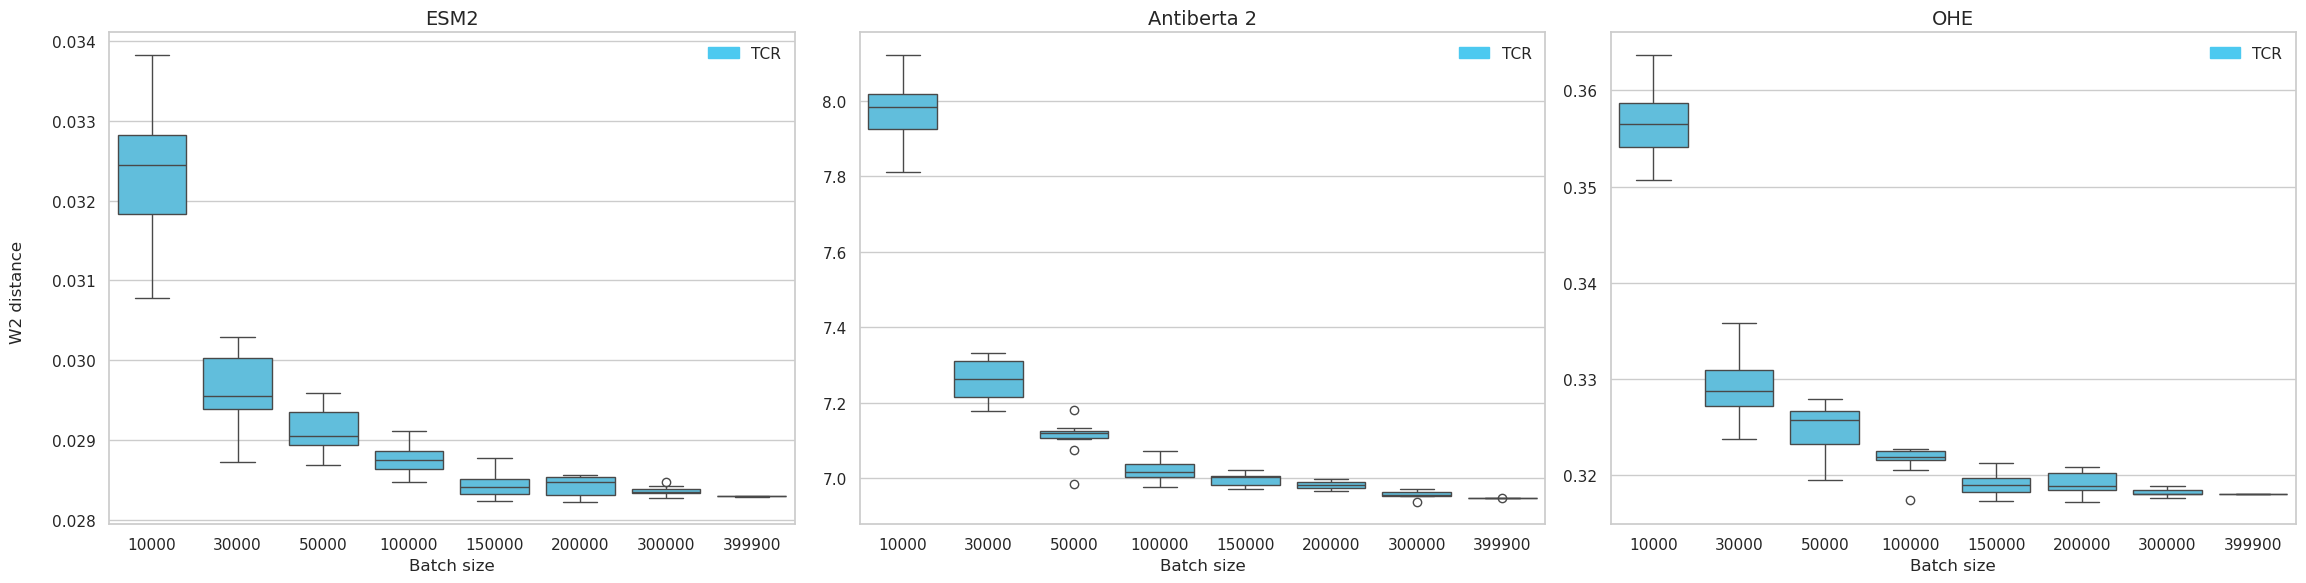

In [23]:
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Define a list of the dataframes and their titles
dataframes = [df_esm2, df_ab2, df_ohe]
titles = ['ESM2', 'Antiberta 2', 'OHE']

# Create a legend entry using a Patch for the specified color
legend_patch = Patch(color='#4CC9F0', label='TCR')

# Iterate over the list of dataframes and axes to plot each boxplot
for ax, df, title in zip(axes, dataframes, titles):
    sns.boxplot(data=df, orient="v", ax=ax, color='#4CC9F0')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    # Add the legend to each subplot
    ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, 'W2 distance', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

# Save the figure with a meaningful name
plt.savefig('completeness_ots.png')
plt.show()

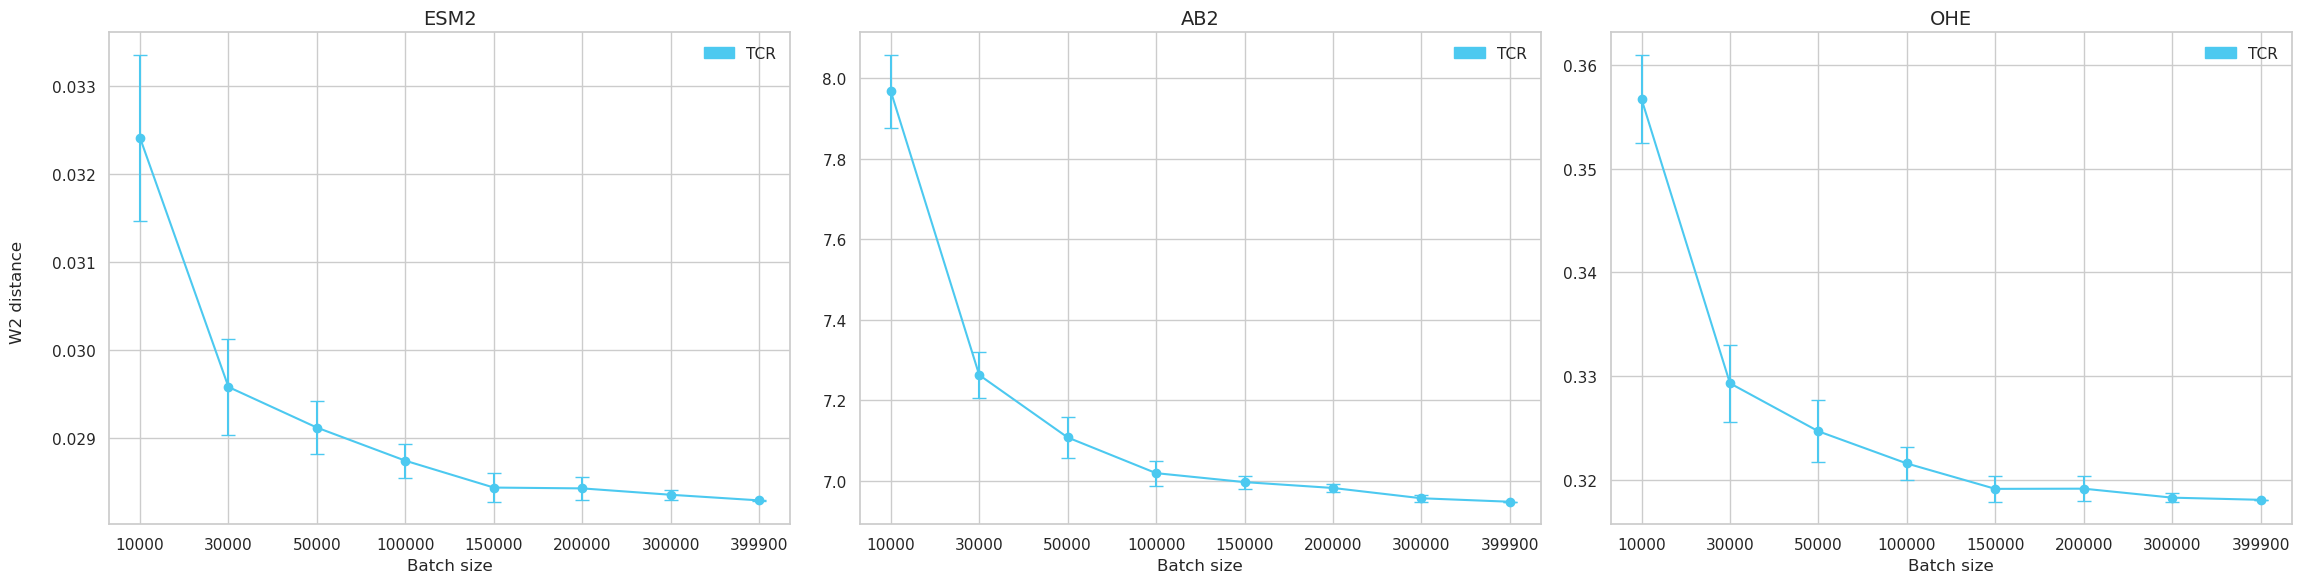

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Define the dataframes and their titles
dataframes = [df_esm2, df_ab2, df_ohe]
titles = ['ESM2', 'AB2', 'OHE']
color = '#4CC9F0'

# Create a legend patch
legend_patch = Patch(color=color, label='TCR')

# Plot error bars instead of boxplots
for ax, df, title in zip(axes, dataframes, titles):
    # Compute mean and std for each column
    means = df.mean()
    stds = df.std()
    x = np.arange(len(means))
    
    # Plot with error bars (connected dots with whiskers)
    ax.errorbar(x, means, yerr=stds, fmt='-o', color=color, capsize=5)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0)
    ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, 'W2 distance', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

# Save the figure
plt.savefig('completeness_ots.png')
plt.show()


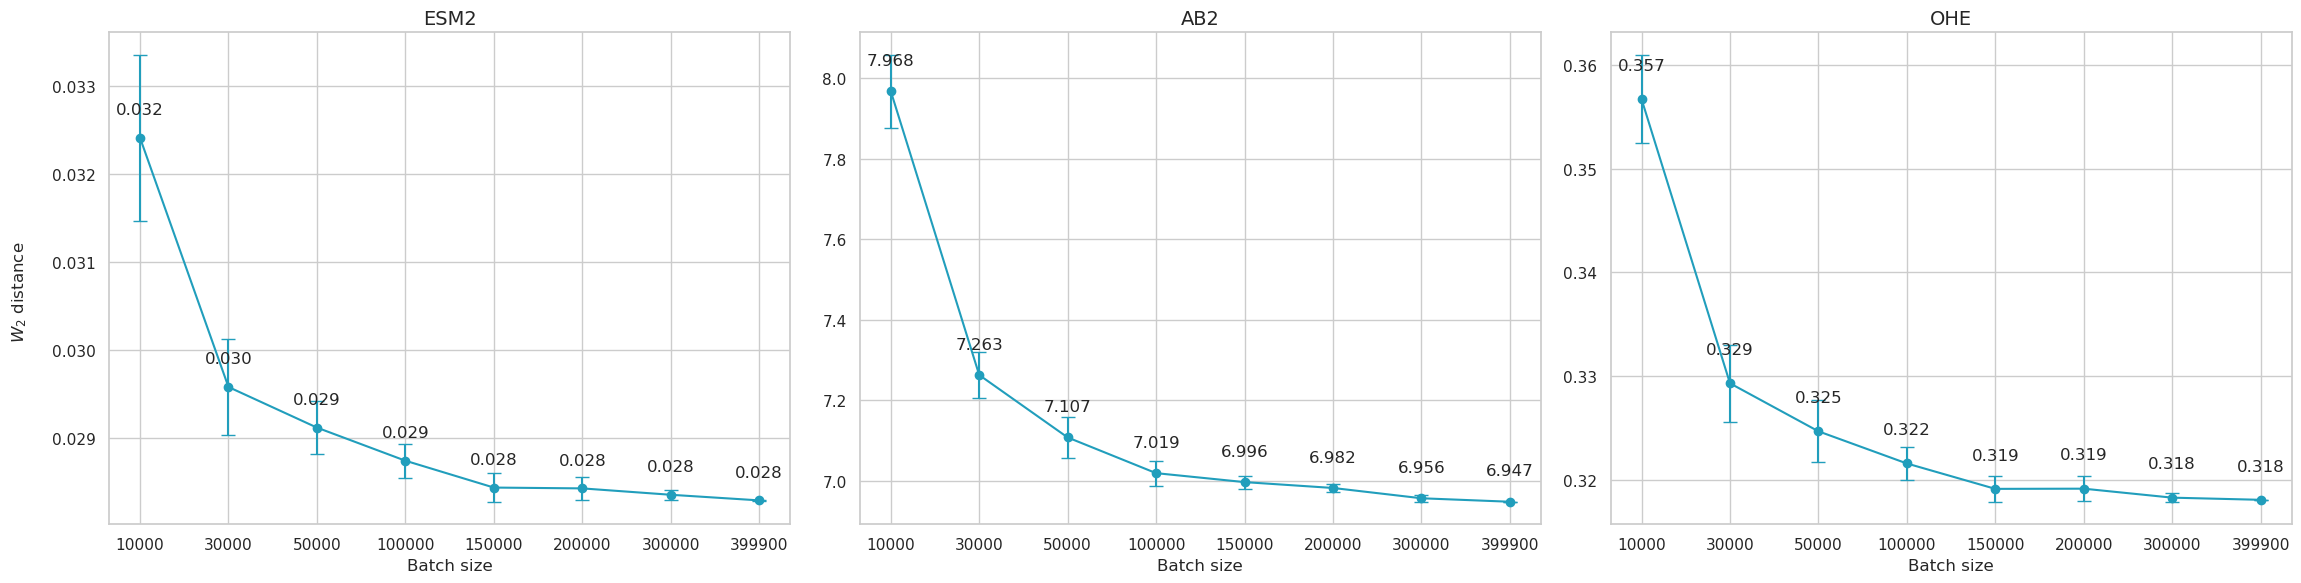

In [35]:
sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Define the dataframes and their titles
dataframes = [df_esm2, df_ab2, df_ohe]
titles = ['ESM2', 'AB2', 'OHE']
color = '#219EBC'  # updated color

# Create a legend patch
#legend_patch = Patch(color=color, label='TCR')

# Plot error bars (connected dots with whiskers) and add numeric labels above markers
for ax, df, title in zip(axes, dataframes, titles):
    means = df.mean()
    stds = df.std()
    x = np.arange(len(means))

    # Plot with error bars
    line = ax.errorbar(x, means, yerr=stds, fmt='-o', color=color, capsize=5)

    # Determine a reasonable vertical offset for labels
    y_range = (means.max() - means.min()) if len(means) > 1 else (stds.max() if len(stds) > 0 else 1.0)
    offset = 0.006 * (means.max() if means.max() != 0 else 1.0) + 0.01 * y_range

    # Add labels above each point
    for xi, yi in zip(x, means):
        ax.text(xi, yi + offset, f'{yi:.3f}', ha='center', va='bottom', fontsize=12)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0)
    # ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, r"$W_2$ distance", va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

# Save the figure
plt.savefig('completeness_ots.png', dpi=300, bbox_inches='tight')
plt.show()

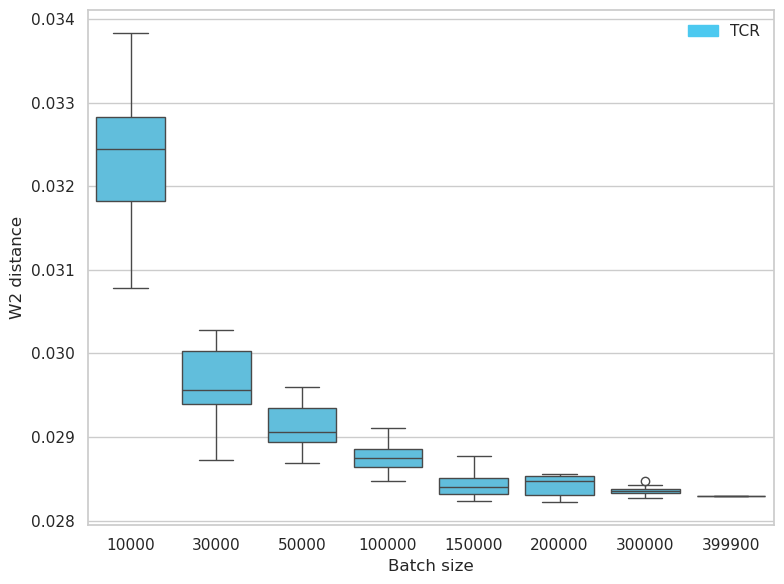

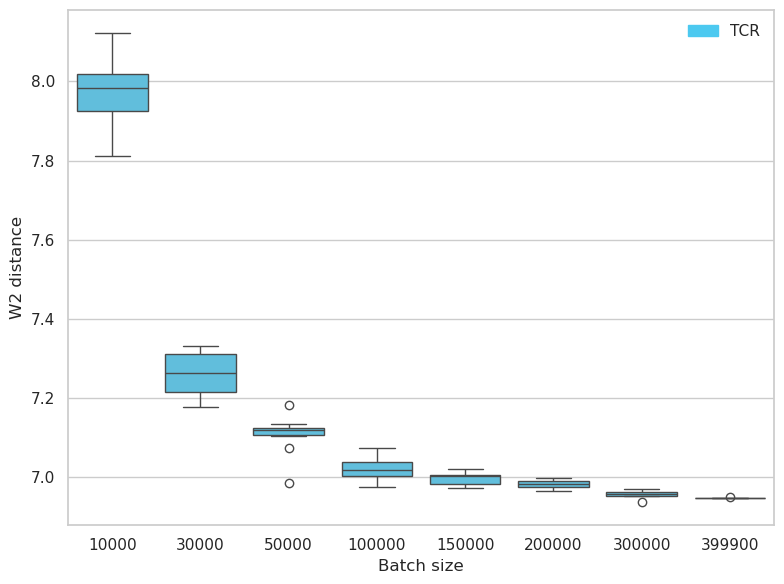

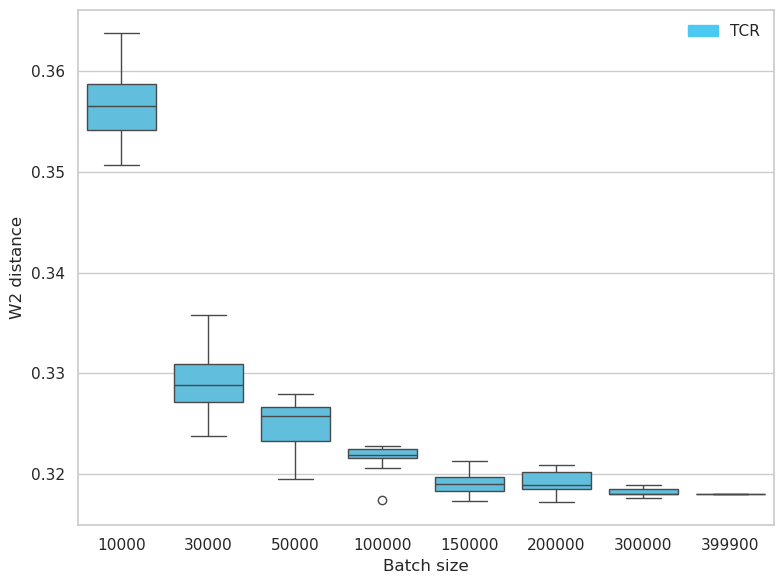

In [11]:
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# Define a list of the dataframes and their titles
dataframes = [df_esm2, df_ab2, df_ohe]
titles = ['ESM2', 'Antiberta 2', 'OHE']

# Create a legend entry using a Patch for the specified color
legend_patch = Patch(color='#4CC9F0', label='TCR')

# Iterate over the list of dataframes and titles to plot each boxplot separately
for df, title in zip(dataframes, titles):
    # Create a figure and axes for the current subplot
    fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

    # Plot the boxplot on the current axes
    sns.boxplot(data=df, orient="v", ax=ax, color='#4CC9F0')

    # Set the title and labels for the current subplot
    #ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    ax.set_ylabel('W2 distance', fontsize=12)  # Add y-axis label

    # Add the legend to the current subplot
    ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

    # Adjust layout for the current subplot
    plt.tight_layout()

    # Save the current subplot with a meaningful name
    plt.savefig(f'completeness_ots_{title}.png')

    # Display the current subplot
    plt.show()

# **Baseline**

In [6]:
df_esm2 = pd.read_csv('data/completeness_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_esm2 = df_esm2.iloc[:, :-1]
df_esm2

,10000,30000,50000,100000,150000,200000,300000
0,0.009427,0.003354,0.002171,0.001285,0.000910,0.000735,0.000568
1,0.010440,0.003570,0.002169,0.001212,0.000917,0.000747,0.000588
2,0.008856,0.003550,0.002198,0.001261,0.000901,0.000732,0.000566
3,0.009611,0.003694,0.002364,0.001291,0.000915,0.000766,0.000579
4,0.009510,0.003659,0.002255,0.001246,0.000926,0.000741,0.000581
5,0.010012,0.003645,0.002217,0.001240,0.000873,0.000740,0.000563
6,0.009574,0.003555,0.002268,0.001302,0.000958,0.000781,0.000594
7,0.009056,0.003679,0.002287,0.001263,0.000892,0.000744,0.000577
8,0.010174,0.003380,0.002213,0.001227,0.000909,0.000754,0.000574
9,0.009123,0.003442,0.002200,0.001324,0.000881,0.000730,0.000579


In [7]:
df_ab2 = pd.read_csv('data/completeness_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ab2 = df_ab2.iloc[:, :-1]
df_ab2

,10000,30000,50000,100000,150000,200000,300000
0,0.987929,0.347906,0.218036,0.122094,0.088788,0.073839,0.056981
1,0.989028,0.344682,0.219129,0.122890,0.089616,0.072492,0.056383
2,0.969796,0.339324,0.216139,0.121106,0.088112,0.072291,0.056113
3,0.974066,0.342969,0.216737,0.120340,0.089483,0.071701,0.056161
4,0.995610,0.347208,0.214505,0.121455,0.087851,0.072518,0.056241
5,0.992682,0.345637,0.213787,0.120442,0.086802,0.071544,0.055913
6,0.985977,0.337354,0.217957,0.121152,0.088888,0.072754,0.056164
7,0.991912,0.348517,0.219100,0.122972,0.088285,0.072886,0.056864
8,0.981738,0.350118,0.216903,0.121343,0.087535,0.072653,0.056312
9,0.995951,0.346384,0.213699,0.119919,0.088177,0.071643,0.055934


In [8]:
df_ohe = pd.read_csv('data/completeness_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ohe = df_ohe.iloc[:, :-1]
df_ohe

,10000,30000,50000,100000,150000,200000,300000
0,0.106248,0.040258,0.026489,0.015763,0.011680,0.009412,0.007893
1,0.110635,0.039163,0.025739,0.015136,0.011678,0.009707,0.007649
2,0.105851,0.040933,0.027203,0.016011,0.010998,0.009359,0.008073
3,0.115131,0.039527,0.026063,0.015595,0.011316,0.009635,0.008023
4,0.107298,0.039474,0.025206,0.014561,0.011607,0.009315,0.007884
5,0.107879,0.039495,0.024635,0.015336,0.011794,0.010127,0.007876
6,0.113597,0.039387,0.025818,0.015302,0.011990,0.009518,0.007667
7,0.106899,0.042400,0.027184,0.016205,0.012100,0.010404,0.007996
8,0.105065,0.039430,0.025198,0.014988,0.011549,0.009663,0.007780
9,0.109467,0.039181,0.026303,0.014834,0.012373,0.010269,0.008139


In [9]:
df_b_1p_esm2 = pd.read_csv('data/baseline_1_patient_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_1p_esm2 = df_b_1p_esm2.iloc[:, :-1]
df_b_1p_esm2

,10000,30000,50000,100000,150000,200000,300000
0,0.010725,0.005719,0.004735,0.003870,0.003538,0.003235,0.003086
1,0.011716,0.005894,0.004206,0.003730,0.003647,0.003224,0.003033
2,0.010841,0.006266,0.004739,0.003478,0.003260,0.003120,0.002940
3,0.011404,0.005437,0.004522,0.003499,0.003258,0.003248,0.003026
4,0.013282,0.005666,0.004280,0.003561,0.003192,0.003103,0.002973
5,0.012121,0.005789,0.004509,0.003698,0.003404,0.003192,0.003009
6,0.012019,0.005902,0.004390,0.003534,0.003234,0.003175,0.002965
7,0.012261,0.005708,0.004590,0.003608,0.003207,0.003177,0.002939
8,0.010402,0.006195,0.004248,0.003841,0.003473,0.003187,0.003002
9,0.012108,0.006147,0.004766,0.003263,0.003436,0.003047,0.002976


In [10]:
df_b_2p_esm2 = pd.read_csv('data/baseline_2_patients_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_2p_esm2 = df_b_2p_esm2.iloc[:, :-1]
df_b_2p_esm2


,10000,30000,50000,100000,150000,200000,300000
0,0.090328,0.079527,0.083468,0.084730,0.081843,0.083808,0.083578
1,0.093896,0.086346,0.085509,0.084169,0.083442,0.083550,0.083691
2,0.092302,0.086322,0.082010,0.082471,0.083613,0.081941,0.082380
3,0.090757,0.086611,0.084302,0.083861,0.082653,0.083687,0.082941
4,0.091351,0.082280,0.084694,0.081497,0.083612,0.082407,0.082796
5,0.093494,0.088024,0.083163,0.081430,0.083401,0.083887,0.082850
6,0.096768,0.087890,0.084893,0.084009,0.084179,0.084035,0.083304
7,0.086249,0.085581,0.085897,0.083937,0.082999,0.082776,0.082918
8,0.090063,0.085373,0.084992,0.083710,0.082556,0.082199,0.082090
9,0.097659,0.084167,0.085383,0.082629,0.082967,0.082681,0.082967


In [11]:
df_b_1p_ab2 = pd.read_csv('data/baseline_1_patient_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_1p_ab2 = df_b_1p_ab2.iloc[:, :-1]
df_b_1p_ab2

,10000,30000,50000,100000,150000,200000,300000
0,1.175678,0.516965,0.372215,0.283504,0.249739,0.237612,0.224592
1,1.100440,0.500385,0.398072,0.284610,0.252864,0.235771,0.220941
2,1.149012,0.534190,0.360207,0.281294,0.241702,0.234943,0.218373
3,1.135438,0.503535,0.364269,0.289557,0.249319,0.232329,0.219861
4,1.121937,0.497094,0.380148,0.280750,0.254163,0.239803,0.225091
5,1.148002,0.511794,0.369945,0.288047,0.260891,0.231760,0.225384
6,1.118634,0.515481,0.380136,0.299621,0.253735,0.232154,0.218560
7,1.084692,0.502604,0.376191,0.289100,0.238919,0.236020,0.218047
8,1.084263,0.499454,0.372349,0.282561,0.255359,0.236980,0.220388
9,1.153348,0.527879,0.355870,0.282829,0.256133,0.238117,0.220493


In [12]:
df_b_2p_ab2 = pd.read_csv('data/baseline_2_patients_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_2p_ab2 = df_b_2p_ab2.iloc[:, :-1]
df_b_2p_ab2

,10000,30000,50000,100000,150000,200000,300000
0,6.831248,6.446989,6.326689,6.178029,6.048712,6.163401,6.077922
1,6.904728,6.352722,6.274394,6.087423,6.078667,6.108583,6.086420
2,7.009840,6.255099,6.302943,6.157638,6.153348,6.129120,6.081052
3,6.967499,6.412125,6.083150,6.085388,6.115941,6.087233,6.089696
4,7.053746,6.367964,6.176808,6.171244,6.123402,6.101583,6.094132
5,7.071902,6.366777,6.114569,6.125651,6.110951,6.099380,6.057654
6,6.623657,6.374505,6.226401,6.153304,6.150449,6.107461,6.071280
7,7.197788,6.538563,6.188590,6.034228,6.092509,6.128650,6.080758
8,6.919138,6.196981,6.331735,6.085311,6.084681,6.039775,6.082635
9,7.009778,6.437048,6.261266,6.065712,6.140073,6.059897,6.089339


In [13]:
df_b_1p_ohe = pd.read_csv('data/baseline_1_patient_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_1p_ohe = df_b_1p_ohe.iloc[:, :-1]
df_b_1p_ohe

,10000,30000,50000,100000,150000,200000,300000
0,0.104074,0.047166,0.031140,0.025974,0.020667,0.019111,0.017906
1,0.107198,0.047400,0.032220,0.024080,0.021905,0.019511,0.017781
2,0.105617,0.045250,0.033469,0.024489,0.021042,0.019610,0.017945
3,0.106442,0.045162,0.034468,0.024980,0.022519,0.019239,0.018152
4,0.109850,0.047480,0.034305,0.024346,0.021748,0.019908,0.017524
5,0.107245,0.044387,0.034082,0.023844,0.020550,0.018783,0.017739
6,0.106920,0.045834,0.033958,0.024217,0.020998,0.019832,0.018237
7,0.106993,0.044476,0.033520,0.024007,0.020756,0.019073,0.018115
8,0.103057,0.046021,0.034176,0.023964,0.020933,0.019114,0.017831
9,0.108064,0.044092,0.032519,0.024477,0.021425,0.019542,0.017663


In [14]:
df_b_2p_ohe = pd.read_csv('data/baseline_2_patients_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_2p_ohe = df_b_2p_ohe.iloc[:, :-1]
df_b_2p_ohe

,10000,30000,50000,100000,150000,200000,300000
0,0.514930,0.434226,0.421906,0.411037,0.403993,0.404628,0.401532
1,0.492004,0.424125,0.416860,0.410692,0.404425,0.402489,0.402375
2,0.517940,0.438004,0.417692,0.411242,0.403179,0.404110,0.402116
3,0.499635,0.422685,0.416220,0.409264,0.402592,0.405945,0.401772
4,0.492436,0.434872,0.418071,0.407741,0.402584,0.401059,0.400794
5,0.497606,0.438394,0.417340,0.404373,0.404748,0.399292,0.400234
6,0.491919,0.434336,0.422524,0.410091,0.404356,0.402272,0.400708
7,0.497237,0.438109,0.423406,0.405142,0.408157,0.404517,0.402826
8,0.503588,0.422550,0.419044,0.415078,0.405977,0.406172,0.402318
9,0.500051,0.435147,0.420007,0.411945,0.402756,0.402062,0.401288


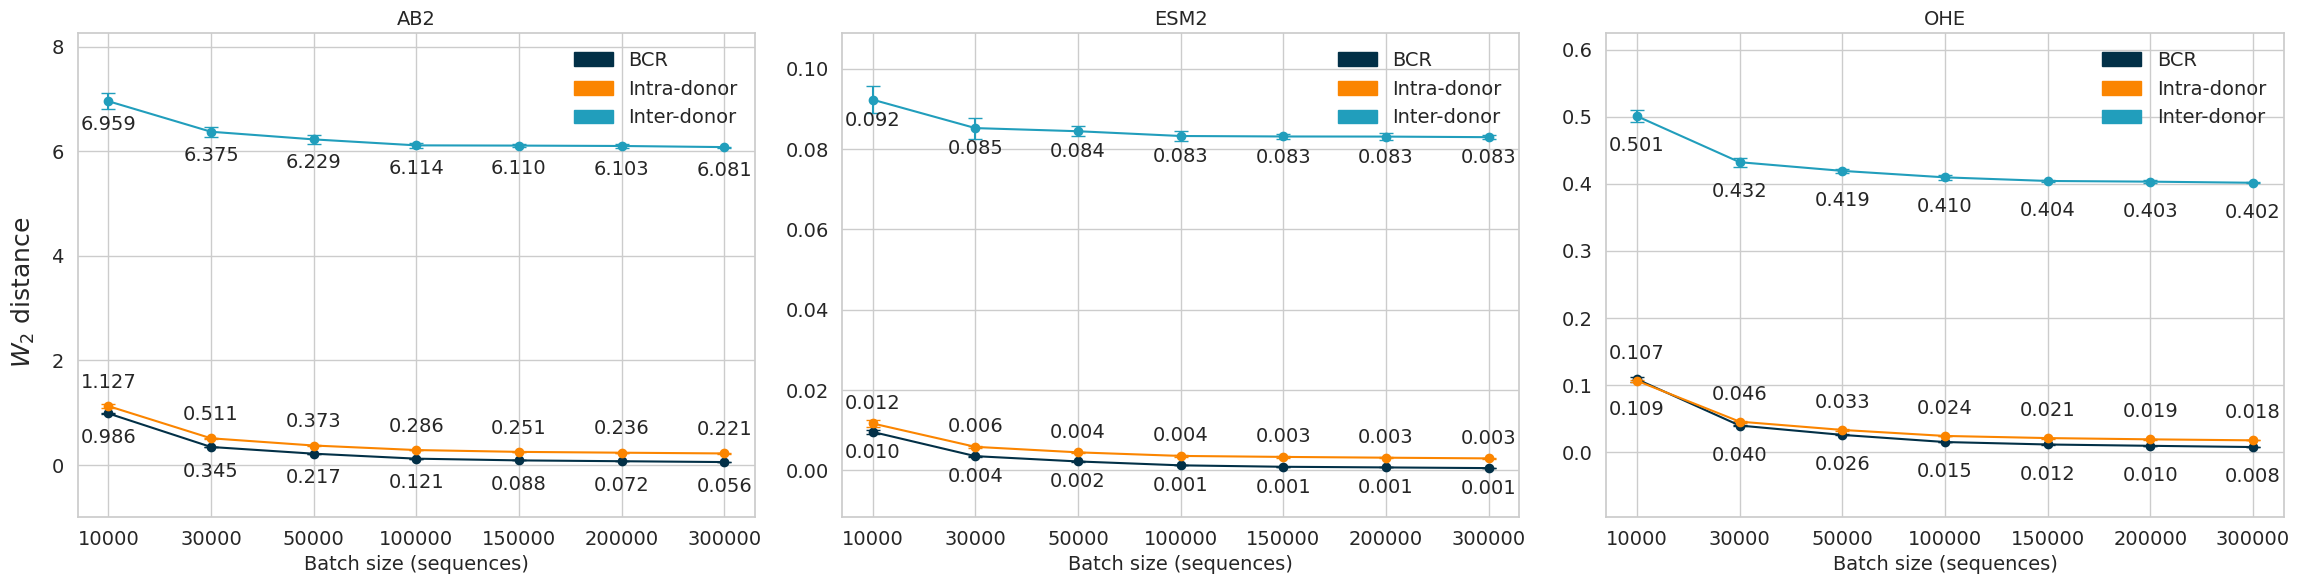

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# DataFrames: assume they all have the same column names (e.g., batch sizes)
titles = ['AB2', 'ESM2','OHE']
labels = ['BCR', 'Intra-donor', 'Inter-donor']
colors = ['#023047', '#FB8500', '#219EBC']

# Grouped datasets
datasets = [
    [df_ab2, df_b_1p_ab2, df_b_2p_ab2],
    [df_esm2, df_b_1p_esm2, df_b_2p_esm2],
    [df_ohe, df_b_1p_ohe, df_b_2p_ohe]
]

# Create legend patches
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l) for c, l in zip(colors, labels)]

# Plot connected means with error bars (whiskers as std)
for ax, title, dfs in zip(axes, titles, datasets):
    all_means = []

    for df, label, color in zip(dfs, labels, colors):
        means = df.mean()
        stds = df.std()
        x = np.arange(len(means))
        all_means.extend(means)

        ax.errorbar(x, means, yerr=stds, label=label, fmt='-o', color=color, capsize=5)

        # Dynamic offset
        y_range = means.max() - means.min()
        offset = y_range * 0.3 if y_range > 0 else 0.1

        # Place labels above or below depending on the line
        for xi, yi in zip(x, means):
            if label == 'Intra-donor':
                ax.text(xi, yi + offset, f'{yi:.3f}', ha='center', va='bottom', fontsize=14)  # Above
            else:
                ax.text(xi, yi - offset, f'{yi:.3f}', ha='center', va='top', fontsize=14)     # Below

    # Set title and labels
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size (sequences)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Expand y-limits to prevent clipping
    ymin, ymax = ax.get_ylim()
    #ax.set_ylim(ymin - y_range * 0.9, ymax + y_range * 0.9)
    ax.set_ylim(ymin - y_range * 0.8, ymax + y_range * 0.9)

    ax.legend(handles=legend_patches, loc='upper right', frameon=False, fontsize=14)


# Set the y-axis label for the entire figure
#fig.text(0.04, 0.5, r'W_2 distance', va='center', rotation='vertical', fontsize=14)
fig.text(0.04, 0.5, r"$W_2$ distance",
         va='center', rotation='vertical', fontsize=18)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

plt.savefig('baseline_completeness.png')
plt.show()


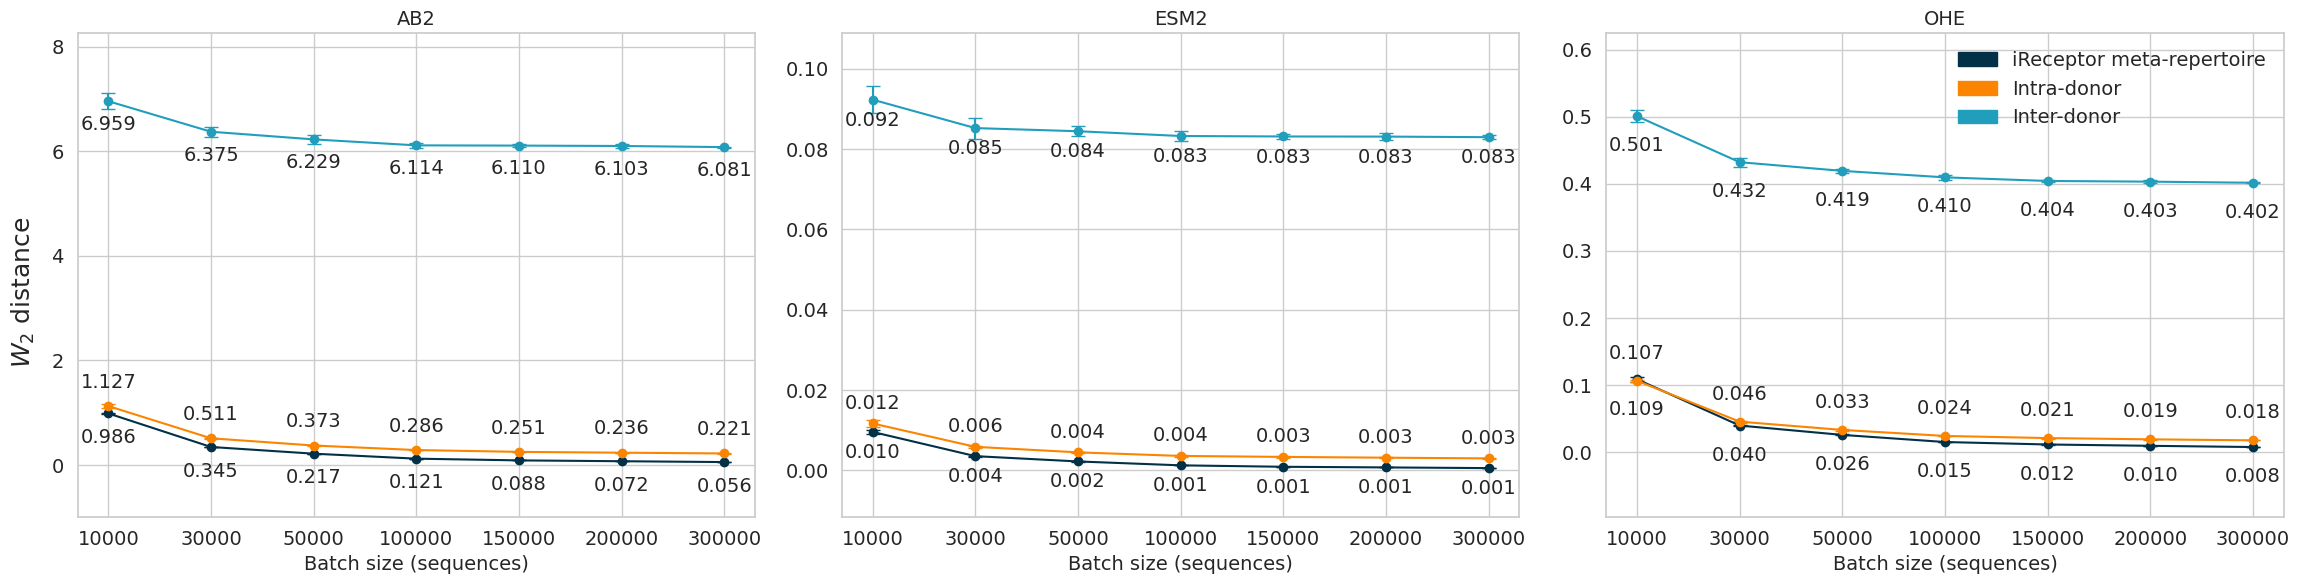

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# DataFrames: assume they all have the same column names (e.g., batch sizes)
titles = ['AB2', 'ESM2', 'OHE']
labels = ['iReceptor meta-repertoire', 'Intra-donor', 'Inter-donor']
colors = ['#023047', '#FB8500', '#219EBC']

# Grouped datasets
datasets = [
    [df_ab2, df_b_1p_ab2, df_b_2p_ab2],
    [df_esm2, df_b_1p_esm2, df_b_2p_esm2],
    [df_ohe, df_b_1p_ohe, df_b_2p_ohe]
]

# Create legend patches (will be used only on the last subplot)
legend_patches = [Patch(color=c, label=l) for c, l in zip(colors, labels)]

# Plot connected means with error bars (whiskers as std)
for ax, title, dfs in zip(axes, titles, datasets):
    all_means = []

    for df, label, color in zip(dfs, labels, colors):
        means = df.mean()
        stds = df.std()
        x = np.arange(len(means))
        all_means.extend(means)

        ax.errorbar(
            x, means, yerr=stds,
            label=label, fmt='-o', color=color, capsize=5
        )

        # Dynamic offset
        y_range = means.max() - means.min()
        offset = y_range * 0.3 if y_range > 0 else 0.1

        # Place labels above or below depending on the line
        for xi, yi in zip(x, means):
            if label == 'Intra-donor':
                ax.text(
                    xi, yi + offset, f'{yi:.3f}',
                    ha='center', va='bottom', fontsize=14
                )  # Above
            else:
                ax.text(
                    xi, yi - offset, f'{yi:.3f}',
                    ha='center', va='top', fontsize=14
                )  # Below

    # Set title and labels
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size (sequences)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Expand y-limits to prevent clipping
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - y_range * 0.8, ymax + y_range * 0.9)

# 🔹 Add legend ONLY on the last (rightmost) subplot
axes[-1].legend(
    handles=legend_patches,
    loc='upper right',
    frameon=False,
    fontsize=14
)

# Global y-axis label for the entire figure
fig.text(
    0.04, 0.5, r"$W_2$ distance",
    va='center', rotation='vertical', fontsize=18
)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

plt.savefig('baseline_completeness.png', dpi=300, bbox_inches='tight')
plt.show()


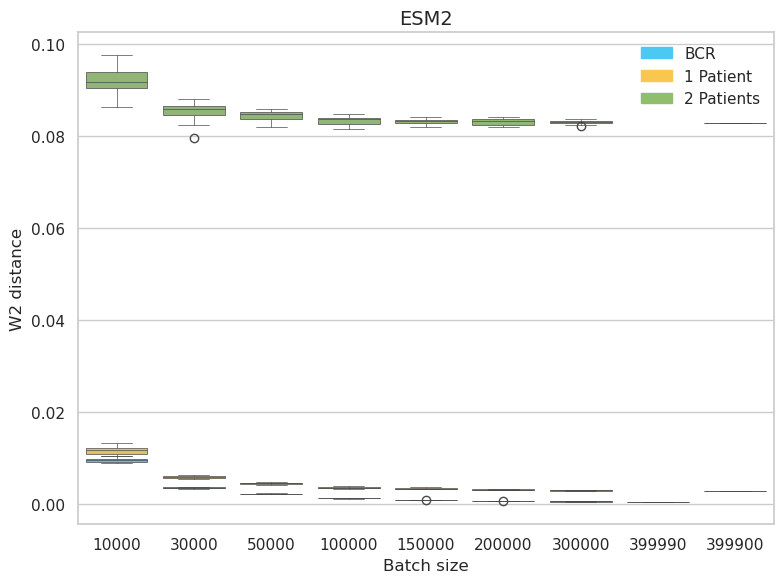

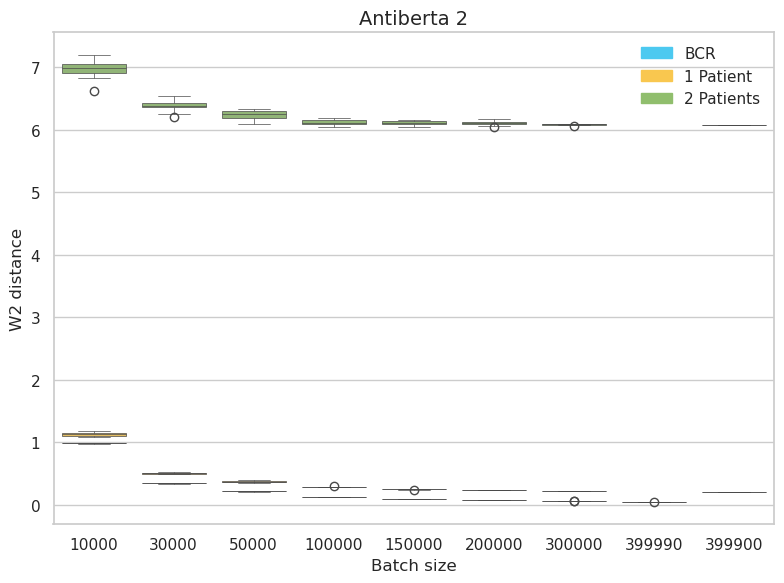

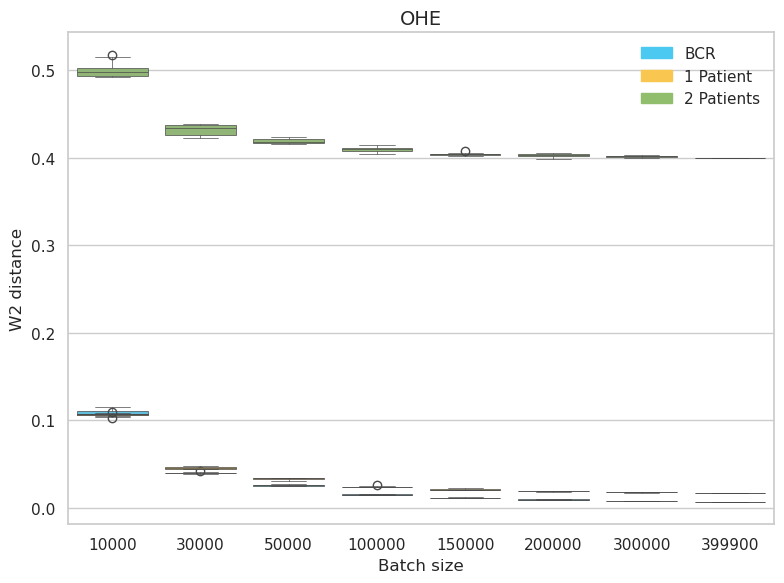

In [31]:
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for seaborn
sns.set_style("whitegrid")

# Define the list of titles and dataframes for each plot
data_info = [
    {
        'title': 'ESM2',
        'dataframes': [df_esm2, df_b_1p_esm2, df_b_2p_esm2],
        'colors': ['#4CC9F0', '#F9C74F', '#90BE6D']
    },
    {
        'title': 'Antiberta 2',
        'dataframes': [df_ab2, df_b_1p_ab2, df_b_2p_ab2],
        'colors': ['#4CC9F0', '#F9C74F', '#90BE6D']
    },
    {
        'title': 'OHE',
        'dataframes': [df_ohe, df_b_1p_ohe, df_b_2p_ohe],
        'colors': ['#4CC9F0', '#F9C74F', '#90BE6D']
    }
]

# Create a legend for the boxplots
legend_patches = [
    Patch(color='#4CC9F0', label='BCR'),
    Patch(color='#F9C74F', label='1 Patient'),
    Patch(color='#90BE6D', label='2 Patients')
]

# Iterate over the data information to create individual plots
for info in data_info:
    fig, ax = plt.subplots(figsize=(8, 6))  # Create a new figure for each dataset
    for df, color in zip(info['dataframes'], info['colors']):
        sns.boxplot(data=df, orient="v", ax=ax, color=color, linewidth=0.5)
    
    # Set the title and labels
    ax.set_title(info['title'], fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    
    # Add the legend
    ax.legend(handles=legend_patches, loc='upper right', frameon=False)
    
    # Set the y-axis label
    ax.set_ylabel('W2 distance', fontsize=12)
    
    # Save the figure with a meaningful name
    plt.tight_layout()
    plt.savefig(f'baseline_completeness_{info["title"].lower()}.png')
    plt.show()  # Show the plot
